In [1]:
import os
import csv
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [3]:
# ── paths ───────────────────────────────────────────────────────────────────
PROJECT = r"C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project"

# original crops: L1000765-68  +  reference.csv
REFERENCE_CSV  = os.path.join(PROJECT, "reference.csv")
SOURCE_TAGS    = ["L1000765", "L1000766", "L1000767", "L1000768"]

# augmented crops
AUG_DIR        = os.path.join(PROJECT, "aug")
AUG_CSV        = os.path.join(PROJECT, "aug.csv")

# ── collect (path, label) pairs ─────────────────────────────────────────────
samples = []   # list of (image_path, label_str)

# 1) original crops from reference.csv
with open(REFERENCE_CSV, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        image_id = row["image_id"].strip()
        card     = row["card"].strip()
        if not image_id or not card:
            continue
        tag, _, idx = image_id.rpartition("_crop_")   # e.g. "L1000765", "0"
        crops_dir = os.path.join(PROJECT, tag, f"crops_{tag}")
        img_path  = os.path.join(crops_dir, f"crop_{idx}.jpg")
        if os.path.isfile(img_path):
            samples.append((img_path, card))
        else:
            print(f"[reference] missing: {img_path}")

# 2) augmented crops from aug.csv
with open(AUG_CSV, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        image_id = row["image_id"].strip()
        card     = row["card"].strip()
        if not image_id or not card:
            continue
        img_path = os.path.join(AUG_DIR, f"{image_id}.jpg")
        if os.path.isfile(img_path):
            samples.append((img_path, card))
        else:
            print(f"[aug] missing: {img_path}")

print(f"Total samples: {len(samples)}")

# ── encode labels ────────────────────────────────────────────────────────────
paths  = [s[0] for s in samples]
labels = [s[1] for s in samples]

le = LabelEncoder()
encoded = le.fit_transform(labels)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# ── train / val split (80 / 20, stratified) ──────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    paths, encoded, test_size=0.2, random_state=42, stratify=encoded
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")


Total samples: 1126
Classes (52): [np.str_('b_1'), np.str_('b_2'), np.str_('b_3'), np.str_('b_4'), np.str_('b_5'), np.str_('b_6'), np.str_('b_7'), np.str_('b_8'), np.str_('b_9'), np.str_('b_draw_2'), np.str_('b_reverse'), np.str_('b_skip'), np.str_('draw_4'), np.str_('g_0'), np.str_('g_1'), np.str_('g_2'), np.str_('g_3'), np.str_('g_4'), np.str_('g_5'), np.str_('g_6'), np.str_('g_7'), np.str_('g_8'), np.str_('g_9'), np.str_('g_draw_2'), np.str_('g_reverse'), np.str_('g_skip'), np.str_('r_0'), np.str_('r_1'), np.str_('r_2'), np.str_('r_3'), np.str_('r_4'), np.str_('r_5'), np.str_('r_6'), np.str_('r_7'), np.str_('r_8'), np.str_('r_9'), np.str_('r_draw_2'), np.str_('r_reverse'), np.str_('r_skip'), np.str_('wild'), np.str_('y_1'), np.str_('y_2'), np.str_('y_3'), np.str_('y_4'), np.str_('y_5'), np.str_('y_6'), np.str_('y_7'), np.str_('y_8'), np.str_('y_9'), np.str_('y_draw_2'), np.str_('y_reverse'), np.str_('y_skip')]
Train: 900  |  Val: 226


In [4]:
# ── Dataset & DataLoaders ────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CardDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), int(self.labels[idx])

train_ds = CardDataset(X_train, y_train, train_tf)
val_ds   = CardDataset(X_val,   y_val,   val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Train batches: 29  |  Val batches: 8


In [5]:
# ── Model: pretrained ResNet-18, replace final layer ────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\UdaRe/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:17<00:00, 2.64MB/s]


In [6]:
# ── Training loop ────────────────────────────────────────────────────────────
EPOCHS = 15

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == lbls).sum().item()
        total        += imgs.size(0)
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # ---- val ----
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total   += imgs.size(0)
    val_losses.append(v_loss / v_total)
    val_accs.append(v_correct / v_total)

    scheduler.step()
    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={train_losses[-1]:.4f}  train_acc={train_accs[-1]:.3f}  "
          f"val_loss={val_losses[-1]:.4f}  val_acc={val_accs[-1]:.3f}")

# save model + label encoder mapping
torch.save(model.state_dict(), os.path.join(PROJECT, "card_classifier.pth"))
np.save(os.path.join(PROJECT, "label_classes.npy"), le.classes_)
print("Model saved to project/card_classifier.pth")


Epoch  1/15  train_loss=2.8816  train_acc=0.394  val_loss=1.3123  val_acc=0.819
Epoch  2/15  train_loss=1.0089  train_acc=0.932  val_loss=0.6902  val_acc=0.907
Epoch  3/15  train_loss=0.4661  train_acc=0.977  val_loss=0.4917  val_acc=0.903
Epoch  4/15  train_loss=0.2596  train_acc=0.989  val_loss=0.4033  val_acc=0.942
Epoch  5/15  train_loss=0.1488  train_acc=0.993  val_loss=0.3265  val_acc=0.929
Epoch  6/15  train_loss=0.1070  train_acc=0.999  val_loss=0.3245  val_acc=0.938
Epoch  7/15  train_loss=0.0819  train_acc=1.000  val_loss=0.3039  val_acc=0.942
Epoch  8/15  train_loss=0.0713  train_acc=1.000  val_loss=0.2944  val_acc=0.942
Epoch  9/15  train_loss=0.0618  train_acc=1.000  val_loss=0.2981  val_acc=0.938
Epoch 10/15  train_loss=0.0566  train_acc=1.000  val_loss=0.2809  val_acc=0.942
Epoch 11/15  train_loss=0.0487  train_acc=1.000  val_loss=0.2667  val_acc=0.942
Epoch 12/15  train_loss=0.0432  train_acc=1.000  val_loss=0.2736  val_acc=0.942
Epoch 13/15  train_loss=0.0381  train_ac

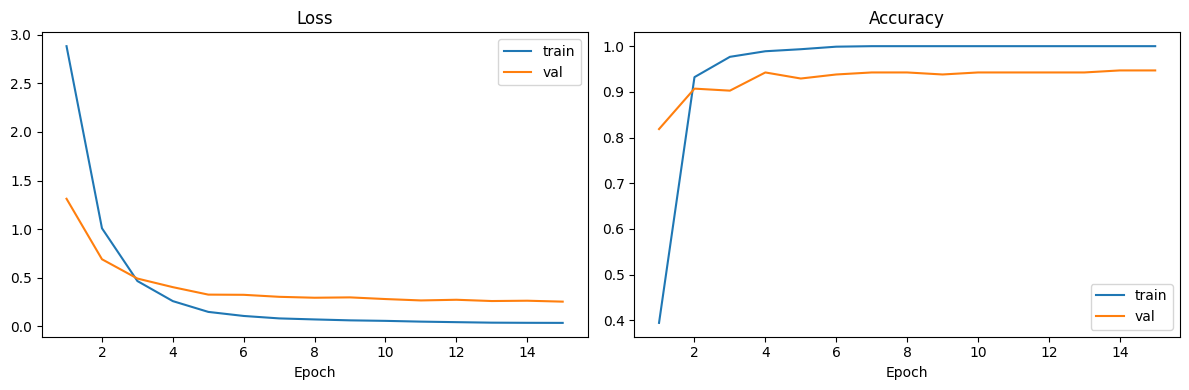


Best val accuracy: 94.7%  (epoch 14)


In [7]:
# ── Plots & final report ─────────────────────────────────────────────────────
epochs_x = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_losses, label="train")
ax1.plot(epochs_x, val_losses,   label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs_x, train_accs, label="train")
ax2.plot(epochs_x, val_accs,   label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nBest val accuracy: {max(val_accs)*100:.1f}%  (epoch {val_accs.index(max(val_accs))+1})")


Wrong predictions: 12 / 226


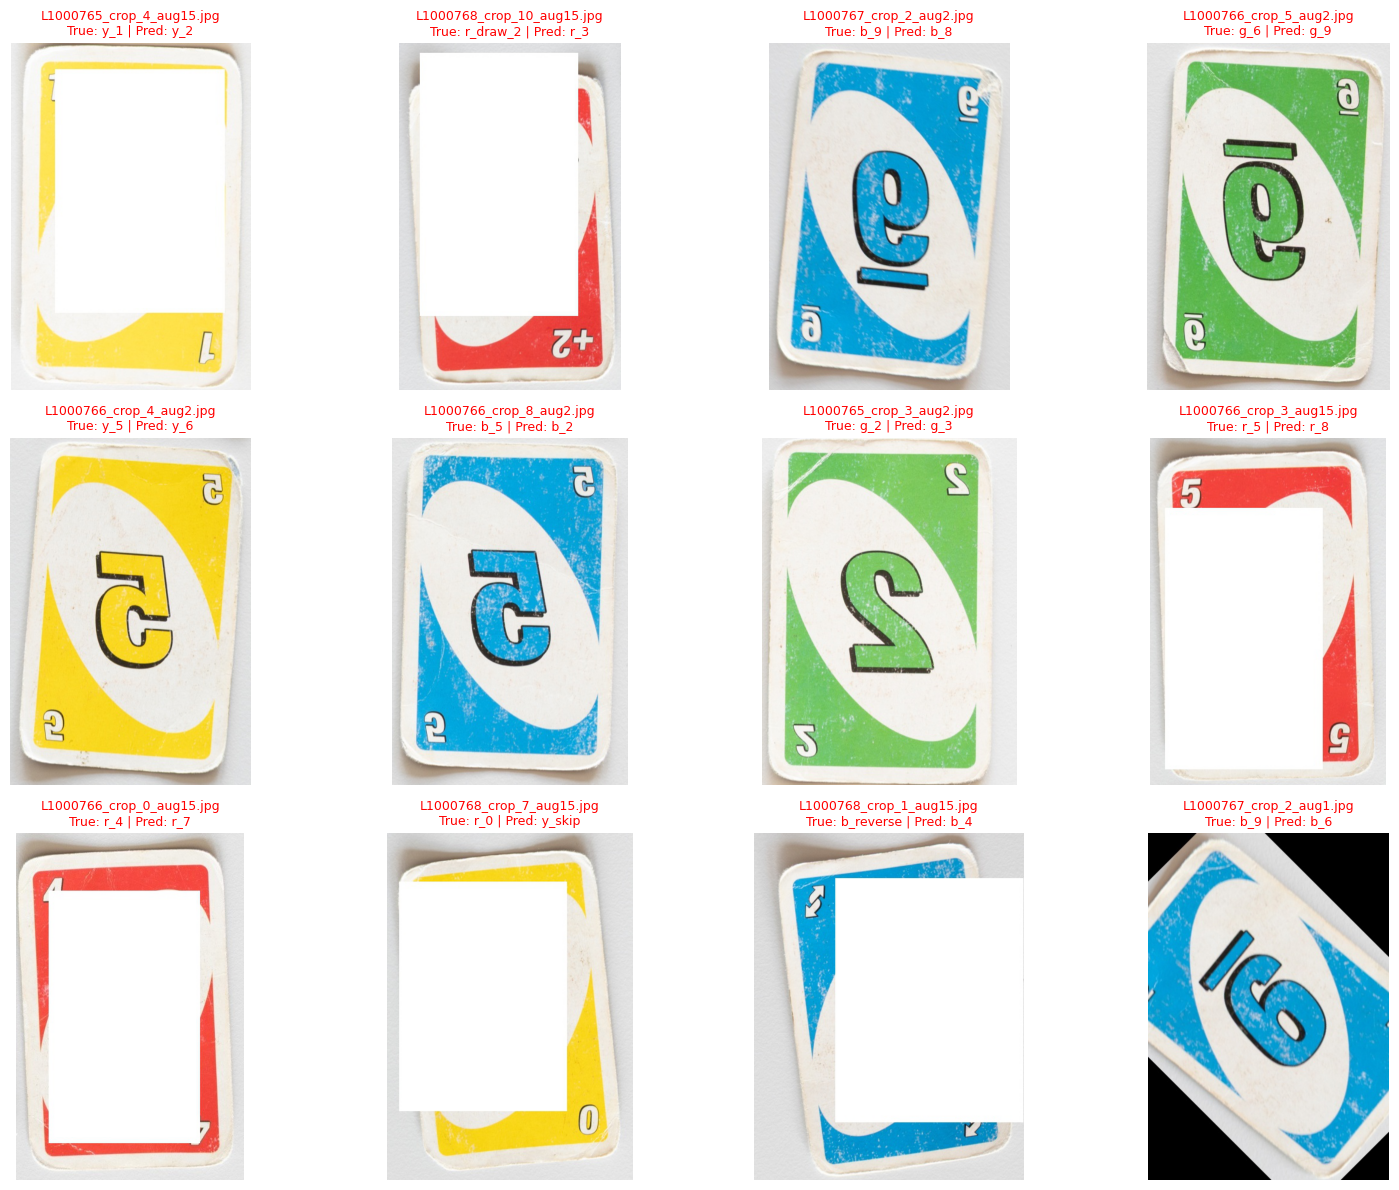

In [9]:
# Show validation images that were predicted incorrectly
import math

class_names = le.classes_

wrong_preds = []  # (img_path, true_idx, pred_idx)
model.eval()

with torch.no_grad():
    for img_path, true_idx in zip(X_val, y_val):
        img = Image.open(img_path).convert("RGB")
        x = val_tf(img).unsqueeze(0).to(device)
        logits = model(x)
        pred_idx = int(torch.argmax(logits, dim=1).item())

        if pred_idx != int(true_idx):
            wrong_preds.append((img_path, int(true_idx), pred_idx))

print(f"Wrong predictions: {len(wrong_preds)} / {len(X_val)}")

if len(wrong_preds) == 0:
    print("Nice, no wrong predictions on the validation split.")
else:
    max_show = min(24, len(wrong_preds))
    cols = 4
    rows = math.ceil(max_show / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i in range(max_show):
        img_path, true_idx, pred_idx = wrong_preds[i]
        img = Image.open(img_path).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(
            f"{os.path.basename(img_path)}\nTrue: {class_names[true_idx]} | Pred: {class_names[pred_idx]}",
            color="red",
            fontsize=9,
        )
        axes[i].axis("off")

    for j in range(max_show, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()